# Stress-testing the one survivor

The condition map left one exploratory candidate. The 4-week per coin trend book on \$10M coins, traded only after a moderate market month, when the market's trailing 4-week move is small against its 12-week volatility.

It was found by looking over the whole sample, so no stretch of these weeks is a holdout for it. This notebook tries to break it three ways. Whether the search that found it would have found it without seeing the future. Whether it survives as a real tradable book rather than a slice. And whether the open interest warning adds anything.

## Setup

Load the shared book. The gate is on in a week when the market's trailing 4-week move sits in the bottom third of every move seen before that week, so it is known at the open and uses no future data. The sleeve is the gated book on the weeks the gate is on, with its entry and exit cost charged.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from book import Book, sharpe
import stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

tb = Book()
W, R, LIQ, VOL, F = tb.W, tb.R, tb.LIQ, tb.VOL, tb.F
run = tb.run

book_w = tb.per_coin(4)
book = run(book_w).net
idx = book.index
gate = (tb.past_cut(tb.strength()) == 1).reindex(idx).fillna(False)
sleeve = tb.sleeve(book_w, gate)
print(f'weeks {len(idx)}   gate on {int(gate.sum())} ({gate.mean():.0%})')
print(f'costed sleeve {sharpe(sleeve):.2f}   outside {sharpe(book[~gate]):.2f}   always on {sharpe(book):.2f}')

weeks 336   gate on 98 (29%)
costed sleeve 1.56   outside 0.67   always on 0.85


## Test one, choosing the condition in each fold

The moderate month was picked from a map of condition thirds after seeing every week. Rerun that choice honestly. Keep the first three years as history, split the rest into four test blocks, and at the start of each block pick the condition third whose sleeve had the best net Sharpe over the weeks before it, among thirds on for at least 20 of them. Trade that sleeve through the block and sit flat when its condition is off.

If the moderate month is a real condition, the search finds it from the past alone and it earns on the weeks after. The stitched test blocks are out of sample for the choice of condition, though not for the six candidates themselves, which were written down after the lane had seen the data.

In [2]:
cells = tb.cells(tb.conditions(), idx)
oos, on_oos, picked = tb.condition_walk_forward(book_w, cells, folds=4, history=156, min_on=20)
print(f'{len(cells)} condition thirds to choose from')
print('picked at the start of each block', {str(k.date()): v for k, v in picked.items()})
print(f'out of sample, gated book         {sharpe(oos):+.2f}   over {len(oos)} weeks')
print(f'out of sample, sleeve             {sharpe(oos[on_oos]):+.2f}   over {int(on_oos.sum())} weeks')
print(f'moderate month sleeve, same span  {sharpe(sleeve.loc[oos.index[0]:]):+.2f}')
print(f'always on, same span              {sharpe(book.loc[oos.index[0]:]):+.2f}')

17 condition thirds to choose from
picked at the start of each block {'2023-04-02': 'market direction high', '2024-02-11': 'market direction high', '2024-12-22': 'funding high', '2025-11-02': 'funding high'}
out of sample, gated book         +0.69   over 180 weeks
out of sample, sleeve             +1.38   over 47 weeks
moderate month sleeve, same span  +1.81
always on, same span              +0.64


The search does not find the moderate month. Choosing among 17 condition thirds on the past alone, it picked trading after a rise for the first two blocks and high funding for the last two.

Its choices still earned. The stitched sleeve makes 1.38 over 47 weeks and the gated book 0.69 over 180, against 0.64 always on over the same span. The moderate month would have made 1.81 over that span, but nothing that saw only the past would have chosen it. Conditioning trend on the market pays out of sample. This particular condition was found by hindsight.

## Test two, as a tradable book

A Sharpe measured only on the weeks the gate is on is not a book anyone trades. The real book runs the trend positions when the gate is on and sits flat when it is off. Read its return, its drawdown, its time in the market and its year by year against the always-on book.

            Sharpe  return/yr  max drawdown  time in mkt
gated         0.91      19.9%         -0.28         29%
always on     0.85      44.9%         -0.58        100%

gate turns on or off 89 times over 336 weeks, about every 4
gated by year {2021: np.float64(1.28), 2022: np.float64(1.8), 2023: np.float64(0.03), 2024: np.float64(0.74), 2025: np.float64(1.84), 2026: np.float64(0.54)}


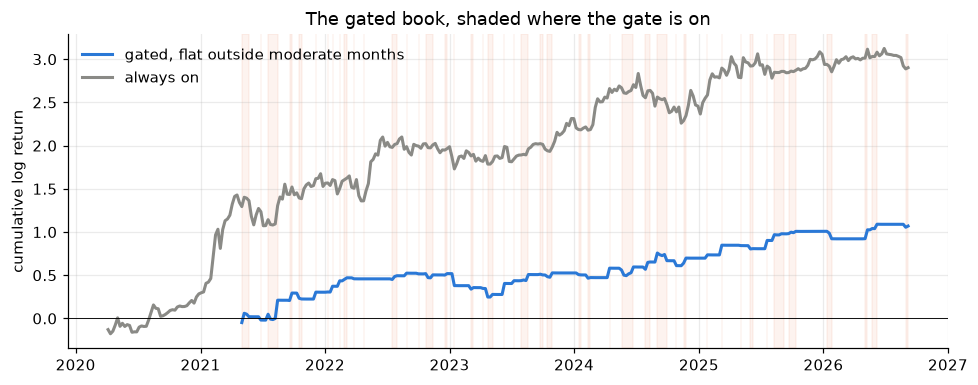

In [3]:
gated_book = run(tb.gated(book_w, gate)).net

def drawdown(x):
    c = x.cumsum()
    return (c - c.cummax()).min()

switches = int((gate.astype(int).diff().abs() == 1).sum())
print(f'{"":10}{"Sharpe":>8}{"return/yr":>11}{"max drawdown":>14}{"time in mkt":>13}')
print(f'{"gated":10}{sharpe(gated_book):>8.2f}{gated_book.mean() * 5200:>10.1f}%{drawdown(gated_book):>14.2f}{gate.mean():>12.0%}')
print(f'{"always on":10}{sharpe(book):>8.2f}{book.mean() * 5200:>10.1f}%{drawdown(book):>14.2f}{1.0:>12.0%}')
print(f'\ngate turns on or off {switches} times over {len(gate)} weeks, about every {len(gate) / switches:.0f}')
print('gated by year', {y: round(sharpe(g), 2) for y, g in gated_book.groupby(gated_book.index.year)})

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(gated_book.index, gated_book.cumsum(), color=BLUE, label='gated, flat outside moderate months')
ax.plot(book.index, book.cumsum(), color=GREY, label='always on')
for lo, hi in zip(idx[gate & ~gate.shift(1, fill_value=False)], idx[gate & ~gate.shift(-1, fill_value=False)]):
    ax.axvspan(lo, hi, color=ORANGE, alpha=0.08)
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('cumulative log return')
ax.set_title('The gated book, shaded where the gate is on'); ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

The gate trades what the always-on book concedes. It makes 0.91 against 0.85, positive in every year, at less than half the drawdown, $-0.28$ against $-0.58$. But it is in the market only 29% of the time and earns 20% a year against 45%. It is a cleaner, smaller book, not a bigger one.

The gate flips on or off 89 times over 336 weeks, roughly every four weeks, and each flip is a full entry or exit. Those trades are charged, in the gated book and in the sleeve.

## Test three, does open interest stack

The mechanism work found trend loses when open interest sits below its recent average. If that is separate information, requiring both a moderate month and open interest above its average should sharpen the book. Split the gated weeks by the open interest level.

In [4]:
majors = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']
oi = stream.open_interest(majors, '2020-09-01', '2026-09-01')
log_contracts = np.log(oi.resample('W-SUN').last().reindex(W.index)).sub(W[majors].cumsum(), axis=0)
oi_level = (log_contracts - log_contracts.rolling(26, min_periods=13).mean()).mean(axis=1).shift(1).reindex(idx)
oi_ok = (oi_level >= oi_level.expanding().median()).reindex(idx).fillna(False)

oi_on, oi_off = gate & oi_level.notna() & oi_ok, gate & oi_level.notna() & ~oi_ok
print(f'moderate month alone        {sharpe(sleeve):+.2f}   ({int(gate.sum())} weeks)')
print(f'moderate and OI at or above {sharpe(tb.sleeve(book_w, oi_on)):+.2f}   ({int(oi_on.sum())} weeks)')
print(f'moderate and OI below       {sharpe(tb.sleeve(book_w, oi_off)):+.2f}   ({int(oi_off.sum())} weeks)')

moderate month alone        +1.56   (98 weeks)
moderate and OI at or above +1.53   (54 weeks)
moderate and OI below       +2.26   (26 weeks)


Open interest does not stack. Requiring it above average cuts the sample from 98 weeks to 54 and leaves the sleeve at 1.53. Inside a moderate month the low open interest weeks are the better ones, 2.26, the opposite of what the always-on book showed. The two conditions overlap rather than add, and on 26 and 54 week slices neither number is worth leaning on.

## Verdict

The candidate does not survive the honest test. Chosen in fold from the past alone, the search never picks the moderate month. It picks trading after a rise and then high funding. Those choices still earn out of sample, 1.38 on the sleeve against 0.64 always on, so conditioning trend on the market state carries something real. The moderate month itself is a hindsight pick.

As a book it is positive every year at half the drawdown of always-on trend, and it does not depend on open interest. It stays exploratory.